# Anomaly detection using ARIMA models

For this example we are using the PMMS data. info here: 
PMMS is published every week as an average of rates for the previous 7 days.

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima.model_selection import train_test_split

In [2]:
# read PMMS data and basic checks
pmms_weekly_data = pd.read_csv('pmms_data.csv')
pmms_weekly_data['week'] = pd.to_datetime(pmms_weekly_data['week'])
display(pmms_weekly_data.head())
print('Data shape before dropping NANs:', pmms_weekly_data.shape)
pmms_weekly_data.dropna(inplace=True)
print('Data shape after dropping NANs:',pmms_weekly_data.shape)

,week,conv_30yr_rate
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


Data shape before dropping NANs: (2868, 2)
Data shape after dropping NANs: (2868, 2)


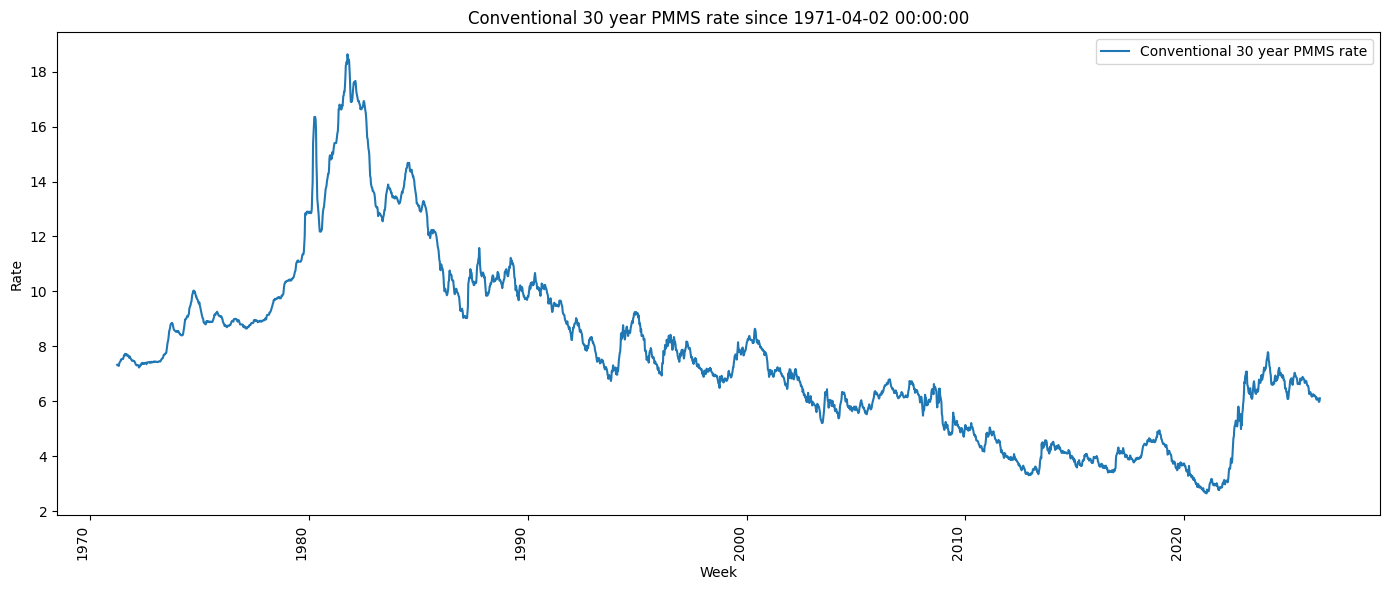

In [3]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(pmms_weekly_data['week'], pmms_weekly_data['conv_30yr_rate'], label = "Conventional 30 year PMMS rate")
plt.legend()
plt.title(f'Conventional 30 year PMMS rate since {pmms_weekly_data['week'].min()}')
plt.xlabel("Week")
plt.ylabel('Rate')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [4]:
# optional
## select a smaller data set to make things faster
subset_date = '2022-01-01'
pmms_weekly_data = pmms_weekly_data[pmms_weekly_data['week']>=subset_date].copy()
print(pmms_weekly_data.shape)

(219, 2)


In [5]:
cutoff_date = '2025-06-01'
train_size = 100
test_size = len(pmms_weekly_data[pmms_weekly_data['week']>=cutoff_date])
pmms_30yr = pmms_weekly_data[-(train_size+test_size):]['conv_30yr_rate'].to_numpy()
train, test = train_test_split(pmms_30yr, train_size=train_size)

arima = pm.auto_arima(train, start_p = 0, start_q = 0, d = 0, max_p = 5, max_q = 5, out_of_sample_size=10, suppress_warnings=True, stepwise=True, error_action='ignore')

In [6]:
arima.order

(2, 0, 1)

In [7]:
confidence_interval_size = 0.01
preds, conf_int = arima.predict(n_periods=test.shape[0], return_conf_int = True, alpha = confidence_interval_size)
# update with most recent data for each new prediction
new_preds = np.array([preds[0]])
new_conf_int = np.array([conf_int[0]])
for i in range(len(test)-1):
    arima.update(test[i])
    joblib.dump(arima, 'arima.pkl')
    pred_tmp, conf_int_tmp = arima.predict(n_periods=1, return_conf_int = True, alpha = confidence_interval_size)
    new_preds = np.append(new_preds, pred_tmp, axis=0)
    new_conf_int = np.append(new_conf_int, conf_int_tmp, axis=0)

In [8]:
preds.shape[0]

41

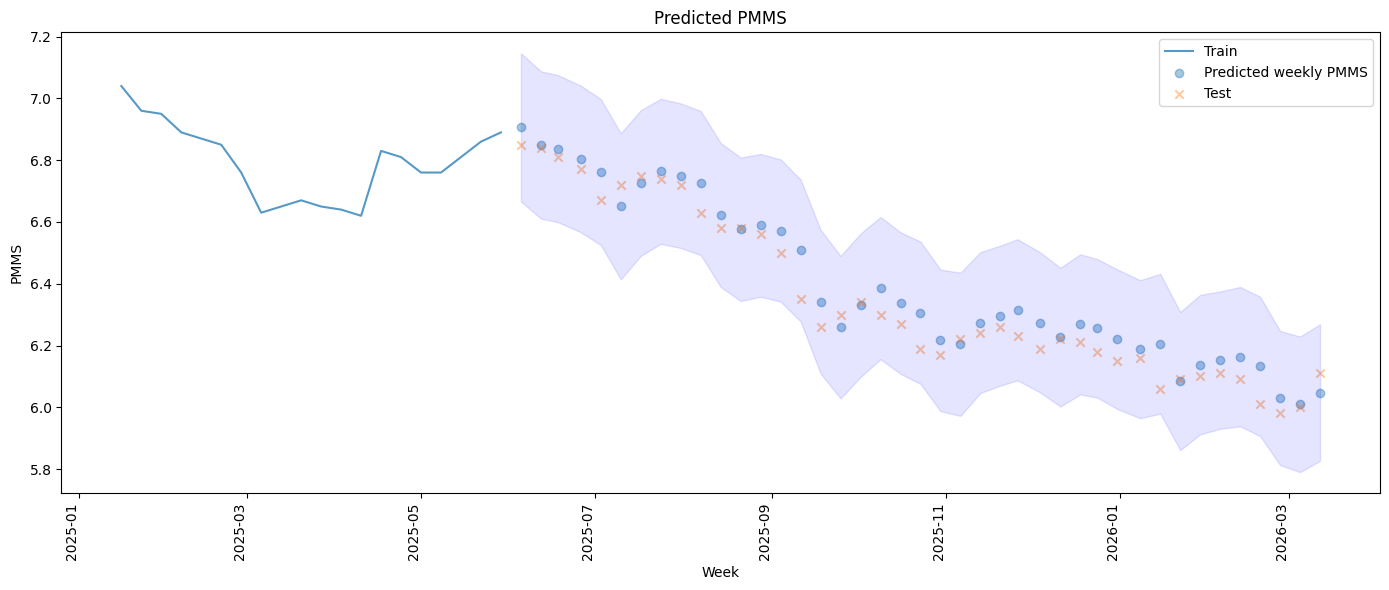

In [9]:
x_dates = pmms_weekly_data['week'][-(20 + preds.shape[0]):]
plt.figure(figsize=(14,6))
plt.plot(x_dates[:20], train[-20:], alpha = 0.75, label = 'Train')
plt.scatter(x_dates[20:], new_preds, alpha = 0.4, marker = 'o', label = 'Predicted weekly PMMS')
plt.scatter(x_dates[20:], test, alpha = 0.4, marker = 'x', label = 'Test')
plt.fill_between(x_dates[-new_preds.shape[0]:], new_conf_int[:, 0], new_conf_int[:, 1], alpha = 0.1, color ='b')
plt.legend()
plt.title('Predicted PMMS')
plt.xlabel("Week")
plt.ylabel('PMMS')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [10]:
# Create fake observations with anomalies
mu = 0 
sigma = train.std() 
noise = np.random.normal(mu, sigma/2, size=test_size)
simulated_predicted_data = test + noise
simulated_predicted_data[2] = simulated_predicted_data[2]+1 # guaranteed outlier
print(simulated_predicted_data)

[6.90256631 6.73280564 7.68745433 6.66532205 6.82139687 6.97736431
 6.93057793 6.6527301  6.83271133 6.7405644  6.18144598 6.96471862
 6.75085473 6.42241542 6.36318363 6.27008777 6.26170537 6.52221719
 6.42885719 6.44218989 6.40253503 6.02520382 6.20916338 6.10711413
 6.52094794 6.13927983 6.2852904  6.15220697 5.85939301 6.06996792
 5.9595781  6.21310813 6.34309229 5.86013073 5.80074571 5.7996392
 6.3289373  6.14609432 6.18721561 5.88198559 5.87624366]


In [11]:
pmms_preds_df = pmms_weekly_data[pmms_weekly_data['week']>=cutoff_date].copy()
pmms_preds_df['arima_predictions'] = new_preds
pmms_preds_df['simulated_predictions'] = simulated_predicted_data
pmms_preds_df['lower_conf_int'] = new_conf_int[:, 0]
pmms_preds_df['upper_conf_int'] = new_conf_int[:, 1]
display(pmms_preds_df.head())

,week,conv_30yr_rate,arima_predictions,simulated_predictions,lower_conf_int,upper_conf_int
2827,2025-06-05,6.85,6.906151,6.902566,6.666218,7.146083
2828,2025-06-12,6.84,6.849441,6.732806,6.610876,7.088006
2829,2025-06-18,6.81,6.837316,7.687454,6.599235,7.075397
2830,2025-06-26,6.77,6.803886,6.665322,6.566652,7.041119
2831,2025-07-03,6.67,6.761257,6.821397,6.524907,6.997607


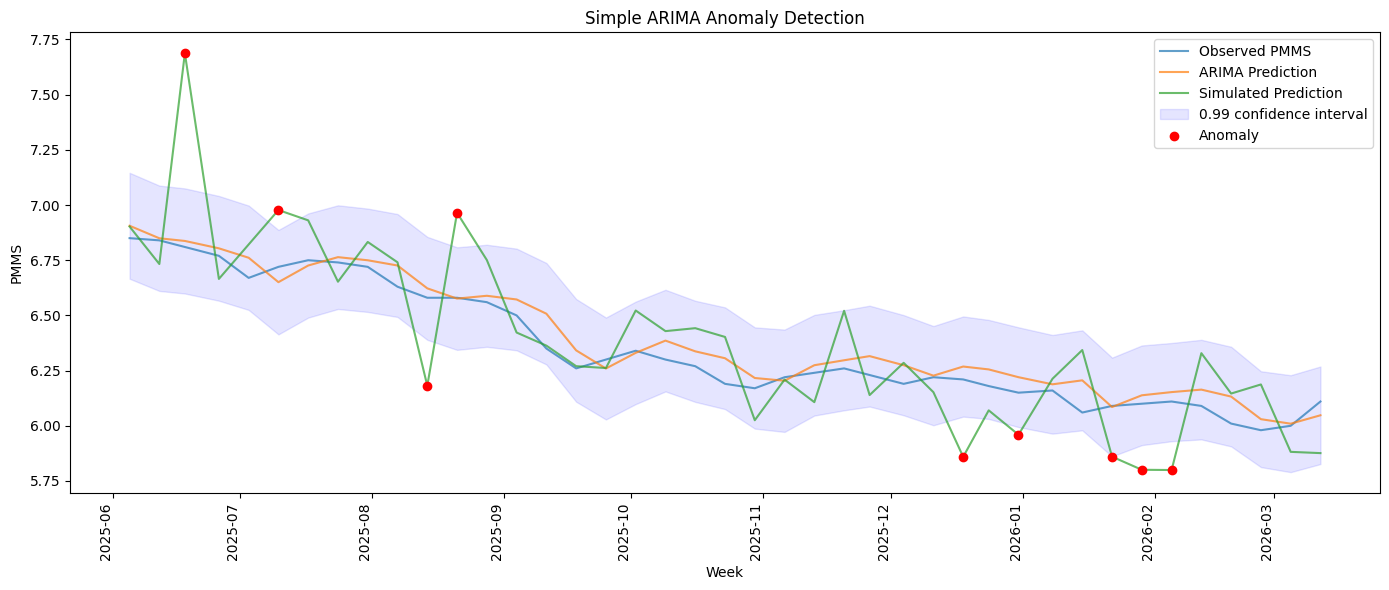

In [12]:
conf_int = 1-confidence_interval_size
plt.figure(figsize=(14, 6))
plt.plot(pmms_preds_df['week'], pmms_preds_df['conv_30yr_rate'], label = 'Observed PMMS', alpha = 0.7)
plt.plot(pmms_preds_df['week'], pmms_preds_df['arima_predictions'], label = 'ARIMA Prediction', alpha = 0.7)
plt.plot(pmms_preds_df['week'], pmms_preds_df['simulated_predictions'], label = 'Simulated Prediction', alpha = 0.7)
plt.fill_between(pmms_preds_df['week'], pmms_preds_df['lower_conf_int'], pmms_preds_df['upper_conf_int'], alpha = 0.1, color ='b', label = f'{conf_int} confidence interval')
# find outliers
outliers = (
    (pmms_preds_df['simulated_predictions']<pmms_preds_df['lower_conf_int'])|
    (pmms_preds_df['simulated_predictions']>pmms_preds_df['upper_conf_int'])
)
plt.scatter(
    pmms_preds_df.loc[outliers, 'week'],
    pmms_preds_df.loc[outliers, 'simulated_predictions'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.legend()
plt.title('Simple ARIMA Anomaly Detection')
plt.xlabel("Week")
plt.ylabel('PMMS')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()